# Getting Started with Chronos-2

[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)



**Chronos-2** is a foundation model for time series forecasting that builds on [Chronos](https://arxiv.org/abs/2403.07815) and [Chronos-Bolt](https://aws.amazon.com/blogs/machine-learning/fast-and-accurate-zero-shot-forecasting-with-chronos-bolt-and-autogluon/). It offers significant improvements in capabilities and can handle diverse forecasting scenarios not supported by earlier models.

| Capability | Chronos | Chronos-Bolt | Chronos-2 |
|------------|---------|--------------|-----------|
| Univariate Forecasting | ✅ | ✅ | ✅ |
| Cross-learning across items | ❌ | ❌ | ✅ |
| Multivariate Forecasting | ❌ | ❌ | ✅ |
| Past-only (real/categorical) covariates | ❌ | ❌ | ✅ |
| Known future (real/categorical) covariates | 🧩 | 🧩 | ✅ |
| Fine-tuning support | ✅ | ✅ | ✅ |
| Max. Context Length | 512 | 2048 | 8192 |

🧩 Chronos/Chronos-Bolt do not natively support future covariates, but they can be combined with external covariate regressors (see [AutoGluon tutorial](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-chronos.html#incorporating-the-covariates)). This only models per-timestep effects, not effects across time. In contrast, Chronos-2 supports all covariate types natively.

More details about Chronos-2 are available in the [technical report](https://www.arxiv.org/abs/2510.15821).

In [ ]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uni

In [ ]:
import os

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
#pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Alternatively, use the following cell to install Chronos

In [ ]:
#!pip install -q pydrive gspread oauth2client gspread-dataframe
#!pip install -q autogluon.timeseries matplotlib pandas numpy openpyxl

#import warnings
#warnings.filterwarnings("ignore")

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from oauth2client.client import GoogleCredentials
#from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [ ]:
#!pip install uv
#!uv pip install -q autogluon.timeseries --system
#!uv pip uninstall -q torchaudio torchvision torchtext --system

## Functions loading

In [ ]:
!pip install workalendar

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.3 MB/s eta 0:00:00
  Created wheel for pymeeus: filename=PyMeeus-0.5.12-py3-none-any.whl size=732000 sha256=7d5a08519e839bf08390cc3235403d00f0b0d373155614b735244a8772e2eda5
  Stored in directory: /root/.cache/pip/wheels/92/74/5d/5cf1193a619dc315b5b0a158876900e21440c71130251307b6
Successfully built pymeeus


In [ ]:
import pandas as pd
import gspread
from google.colab import auth
from google.auth import default
from datetime import datetime, timedelta


def excel_date_to_datetime(excel_date):
    """
    Convierte un número de serie de Excel a datetime.
    """
    return datetime(1899, 12, 30) + timedelta(days=float(excel_date))


def parse_mixed_date_column(series: pd.Series) -> pd.Series:
    """
    Convierte una columna con posibles fechas en varios formatos:
    - año: 2024
    - serial Excel/Google Sheets: 42736
    - string tipo dd/mm/yyyy
    """
    s = series.astype(str).str.strip()
    result = pd.Series(pd.NaT, index=series.index, dtype='datetime64[ns]')

    # 1) Año de 4 dígitos
    mask_year = s.str.match(r'^\d{4}$', na=False)
    if mask_year.any():
        result.loc[mask_year] = pd.to_datetime(
            s.loc[mask_year] + '-12-01',
            format='%Y-%m-%d',
            errors='coerce'
        )

    # 2) Serial Excel / Google Sheets
    mask_remaining = result.isna()
    serials = pd.to_numeric(s.loc[mask_remaining], errors='coerce')
    valid_serials = serials.notna()
    if valid_serials.any():
        result.loc[serials.loc[valid_serials].index] = serials.loc[valid_serials].apply(
            excel_date_to_datetime
        )

    # 3) Strings fecha
    mask_remaining = result.isna()
    if mask_remaining.any():
        result.loc[mask_remaining] = pd.to_datetime(
            s.loc[mask_remaining],
            dayfirst=True,
            errors='coerce'
        )

    return result


def load_gsheet_benchmarks(
    sheet_id: str,
    sheet_name: str,
    header_row: int = 2,
    data_start_row: int = 3
) -> pd.DataFrame:
    """
    Carga y limpia datos de un Google Sheet en un DataFrame.

    Reglas:
    - Si existe 'Date', la convierte a datetime.
    - Si existe 'timestamp', la convierte a datetime.
    - No pone ninguna columna como índice.
    - Convierte a numérico solo las columnas que realmente lo parezcan.
    """
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    ws = gc.open_by_key(sheet_id).worksheet(sheet_name)
    rows = ws.get_all_values(value_render_option='UNFORMATTED_VALUE')

    header = [str(col).strip() for col in rows[header_row]]
    n_cols = len(header)
    data_rows = rows[data_start_row:]

    df = pd.DataFrame(
        [row[:n_cols] for row in data_rows],
        columns=header
    )

    df.columns = df.columns.str.strip()

    # Convertir columnas de fecha, pero NO ponerlas como índice
    for date_col in ['Date', 'timestamp']:
        if date_col in df.columns:
            df[date_col] = parse_mixed_date_column(df[date_col])

    # Convertir a numérico solo columnas no-fecha
    for col in df.columns:
        if col in ['Date', 'timestamp']:
            continue

        converted = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

        # Solo convertir si realmente parece una columna numérica
        if converted.notna().sum() > 0:
            df[col] = converted

    return df

In [ ]:
def add_calendar_covariates(df):
    import numpy as np
    import pandas as pd
    from workalendar.europe import Spain

    df = df.copy()
    ts = pd.to_datetime(df["timestamp"])

    cal = Spain()

    # =========================
    # BASE
    # =========================
    df["dow"] = ts.dt.dayofweek
    df["month"] = ts.dt.month
    df["day"] = ts.dt.day
    df["week"] = ts.dt.isocalendar().week.astype(int)

    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # =========================
    # CICLICAS
    # =========================
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # =========================
    # FESTIVOS (WORKALENDAR)
    # =========================
    df["is_holiday"] = ts.apply(lambda d: cal.is_holiday(d)).astype(int)

    # Día laborable real (muy útil)
    df["is_working_day"] = ts.apply(lambda d: cal.is_working_day(d)).astype(int)

    # Pre-festivo
    df["is_pre_holiday"] = ts.apply(
        lambda d: cal.is_holiday(d + pd.Timedelta(days=1))
    ).astype(int)

    # Post-festivo
    df["is_post_holiday"] = ts.apply(
        lambda d: cal.is_holiday(d - pd.Timedelta(days=1))
    ).astype(int)

    # Puente (día entre festivo y finde o viceversa)
    df["is_bridge_day"] = (
        df["is_working_day"] &
        (
            df["is_pre_holiday"] |
            df["is_post_holiday"]
        )
    ).astype(int)

    # =========================
    # SEMANA SANTA (🔥 CLAVE)
    # =========================
    def is_easter_window(d):
        easter = pd.Timestamp(cal.get_easter_sunday(d.year))  # 🔥 FIX
        return (easter - pd.Timedelta(days=7)) <= d <= (easter + pd.Timedelta(days=1))

    df["is_easter_week"] = ts.apply(is_easter_window).astype(int)

    # =========================
    # PAYROLL (🔥 MUY CLAVE)
    # =========================
    df["is_payday_window"] = ((df["day"] >= 20) & (df["day"] <= 31)).astype(int)

    # =========================
    # FIN DE MES
    # =========================
    df["days_to_month_end"] = (ts + pd.offsets.MonthEnd(0) - ts).dt.days

    # =========================
    # PERIODOS COMERCIALES
    # =========================
    df["is_christmas"] = (df["month"] == 12).astype(int)
    df["is_january_sales"] = ((df["month"] == 1) & (df["day"] <= 15)).astype(int)
    df["is_black_friday"] = ((df["month"] == 11) & (df["day"] >= 20)).astype(int)

    # =========================
    # ESTACIONALIDAD
    # =========================
    df["is_summer"] = df["month"].isin([7, 8]).astype(int)

    return df

## Load Data

### BD Indicator - Consumption

In [ ]:
# 1) Data loading:
df_indicators = load_gsheet_benchmarks(
     sheet_id='1hakzOf9fUA8dA9TLxeph4wrd3EpWUWS0jI8QbzfGBsg',     #    <- Change the doc name to use your data
     sheet_name='Consumo_BD'                                      #    <- Change the sheet name to use your data
)

context_df = df_indicators.copy()
context_df.head()

,item_id,timestamp,target
0,Consumo_BD,2017-01-01,789.172
1,Consumo_BD,2017-01-02,1731.510
2,Consumo_BD,2017-01-03,1919.130
3,Consumo_BD,2017-01-04,1972.950
4,Consumo_BD,2017-01-05,2035.940


## Multivariate Forecasting (Calendar)

We start with a simple multivariate forecasting example using the pandas API + calendar dummies

### Forecast Estático (ejemplo inicial)

In [ ]:
# Load data as a long-format pandas data frame
#context_df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

context_df = add_calendar_covariates(context_df)
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

Input dataframe shape: (3286, 3)


,item_id,timestamp,target
0,Consumo_BD,2017-01-01,789.172
1,Consumo_BD,2017-01-02,1731.510
2,Consumo_BD,2017-01-03,1919.130
3,Consumo_BD,2017-01-04,1972.950
4,Consumo_BD,2017-01-05,2035.940


Input dataframe shape: (3286, 24)


,item_id,timestamp,target,dow,month,day,week,is_weekend,dow_sin,dow_cos,...,is_pre_holiday,is_post_holiday,is_bridge_day,is_easter_week,is_payday_window,days_to_month_end,is_christmas,is_january_sales,is_black_friday,is_summer
0,Consumo_BD,2017-01-01,789.172,6,1,1,52,1,-0.781831,0.623490,...,0,0,0,0,0,30,0,1,0,0
1,Consumo_BD,2017-01-02,1731.510,0,1,2,1,0,0.000000,1.000000,...,0,1,1,0,0,29,0,1,0,0
2,Consumo_BD,2017-01-03,1919.130,1,1,3,1,0,0.781831,0.623490,...,0,0,0,0,0,28,0,1,0,0
3,Consumo_BD,2017-01-04,1972.950,2,1,4,1,0,0.974928,-0.222521,...,0,0,0,0,0,27,0,1,0,0
4,Consumo_BD,2017-01-05,2035.940,3,1,5,1,0,0.433884,-0.900969,...,1,0,1,0,0,26,0,1,0,0


In [ ]:
# Create future covariates (calendar variables)
h=24
future_dates = pd.date_range(
    start=context_df["timestamp"].max() + pd.Timedelta(days=1),
    periods=h,
    freq="D"  # o "H" si es hourly
)


future_df = pd.DataFrame({
    "item_id": "Consumo_BD",
    "timestamp": future_dates
})


future_df = add_calendar_covariates(future_df)



In [ ]:
# Forecast out-of-sample (24 periods ahead for each month - item_id)
pred_df = pipeline.predict_df(context_df, future_df=future_df, prediction_length=h, quantile_levels=[0.1, 0.5, 0.9] )
#pred_df = pipeline.predict_df(context_df, prediction_length=h, quantile_levels=[0.1, 0.5, 0.9])

print("Output dataframe shape:", pred_df.shape)
display(pred_df.head())

Output dataframe shape: (24, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,Consumo_BD,2025-12-31,target,1821.233154,1673.351929,1821.233154,1961.069092
1,Consumo_BD,2026-01-01,target,1118.447754,962.350159,1118.447754,1267.406250
2,Consumo_BD,2026-01-02,target,1971.217651,1861.961548,1971.217651,2082.252930
3,Consumo_BD,2026-01-03,target,1800.889038,1679.523804,1800.889038,1921.708984
4,Consumo_BD,2026-01-04,target,1604.170776,1472.495850,1604.170776,1721.776733


**predict_df** supports the following arguments:
- `df`: Long-format DataFrame with id, timestamp, and target column(s)
- `future_df`: Optional DataFrame with future covariates (columns present in both df and future_df are treated as known future covariates)
- `id_column`: Column with time series identifiers (default: "item_id") - e.g.: Geographies (individual) or different datasets (retail sales, traffic, electricity price, etc)
- `timestamp_column`: Column with timestamps (default: "timestamp") - e.g.: Time series with all hours of all days in a month
- `target`: Target column name(s) to forecast (default: "target")
- `prediction_length`: Number of steps to forecast
- `quantile_levels`: Quantiles to compute (default: [0.1, 0.2, ..., 0.9])

Returns a DataFrame with forecasts including point predictions and quantiles.
- For each item_id (H1,... , H414) makes a h steps (h days) forecast. For this reason the output has dimension 9936 (n. series (item_id) * prediction_length)
- It has a panel data structure. It has group-attention (panel structure)



In [ ]:
# Forecast out-of-sample by passing the test sample (with observations we have)

import pandas as pd
import numpy as np

# =========================
# 1. CONFIGURATION
# =========================

# Forecast horizon: number of future steps to predict for each series
h = 31

# Ensure the dataset is sorted by series ID and timestamp
df = context_df.sort_values(["item_id", "timestamp"]).copy()


# Keep only series with enough history:
# each series must have more than h observations so that
# we can reserve the last h points as test data
valid_ids = df.groupby("item_id").size()
valid_ids = valid_ids[valid_ids > h].index
df = df[df["item_id"].isin(valid_ids)].copy()

# Print basic dataset info
print("Number of valid series:", df["item_id"].nunique())
print("Full dataset shape:", df.shape)


# =========================
# 2. TRAIN / TEST SPLIT
# =========================

# Reserve the last h observations of each series as test set
test_df = (
    df.groupby("item_id", group_keys=False)
      .tail(h)
      .copy()
)

# Use all previous observations as training set
train_df = (
    df.groupby("item_id", group_keys=False)
      .apply(lambda x: x.iloc[:-h])
      .reset_index(drop=True)
      .copy()
)

# Print split shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


# =========================
# 3. FORECAST GENERATION
# =========================
# Generate h-step-ahead forecasts using only the training data
# Quantiles are included to obtain probabilistic forecasts
#pred_df_observations = pipeline.predict_df(
#    train_df,
#    prediction_length=h,
#    quantile_levels=[0.1, 0.5, 0.9]
#)
# Print prediction output info
#print("Prediction dataframe shape:", pred_df_observations.shape)
#display(pred_df_observations.head())

# =========================
# 3. FORECAST GENERATION (WITH FUTURE COVARIATES)
# =========================
# Construir future_df a partir del test (sin target)
future_df = test_df.drop(columns=["target"]).copy()
# Asegurar que tiene covariables (si no las añadiste antes)
# (esto es seguro aunque ya estén)
future_df = add_calendar_covariates(future_df)
# Generar predicciones usando covariables futuras
pred_df_observations = pipeline.predict_df(
    train_df,
    future_df=future_df,
    prediction_length=h,
    quantile_levels=[0.1, 0.5, 0.9]
)

print("Prediction dataframe shape:", pred_df_observations.shape)
display(pred_df_observations.head())



# =========================
# 4. MERGE FORECASTS WITH ACTUAL OBSERVATIONS
# =========================

# Merge predictions with the actual observed values from the test set
# This allows direct comparison between forecast and ground truth

# Make sure the timestamp column has the same dtype in both dataframes
pred_df_observations["timestamp"] = pd.to_datetime(pred_df_observations["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])


eval_df = pred_df_observations.merge(
    test_df[["item_id", "timestamp", "target"]],
    on=["item_id", "timestamp"],
    how="inner"
)

# Print merged evaluation dataset info
print("Evaluation dataframe shape:", eval_df.shape)
display(eval_df.head())


# =========================
# 5. POINT FORECAST GOODNESS OF FIT
# =========================

# Compute standard forecast errors for the point forecast
eval_df["error"] = eval_df["predictions"] - eval_df["target"]
eval_df["abs_error"] = eval_df["error"].abs()
eval_df["sq_error"] = eval_df["error"] ** 2

# Compute percentage errors, avoiding division by zero
eval_df["ape"] = np.where(
    eval_df["target"] != 0,
    eval_df["abs_error"] / eval_df["target"].abs(),
    np.nan
)

# Compute symmetric absolute percentage error (sMAPE)
eval_df["smape"] = np.where(
    (eval_df["target"].abs() + eval_df["predictions"].abs()) != 0,
    2 * eval_df["abs_error"] / (eval_df["target"].abs() + eval_df["predictions"].abs()),
    np.nan
)

# Aggregate global metrics
mae = eval_df["abs_error"].mean()
rmse = np.sqrt(eval_df["sq_error"].mean())
mape = eval_df["ape"].mean() * 100
smape = eval_df["smape"].mean() * 100

# Compute R-squared as an additional goodness-of-fit metric
ss_res = eval_df["sq_error"].sum()
ss_tot = ((eval_df["target"] - eval_df["target"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

# Print global GoF metrics
print("\n=== Global Point Forecast Metrics ===")
print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAPE:  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")
print(f"R^2:   {r2:.4f}")


# =========================
# 6. QUANTILE GOODNESS OF FIT
# =========================

# Define pinball loss function for quantile forecasts
def pinball_loss(y_true, y_pred, q):
    return np.where(
        y_true >= y_pred,
        q * (y_true - y_pred),
        (1 - q) * (y_pred - y_true)
    )

# Compute pinball loss for each requested quantile
eval_df["pinball_0.1"] = pinball_loss(eval_df["target"], eval_df["0.1"], 0.1)
eval_df["pinball_0.5"] = pinball_loss(eval_df["target"], eval_df["0.5"], 0.5)
eval_df["pinball_0.9"] = pinball_loss(eval_df["target"], eval_df["0.9"], 0.9)

# Aggregate pinball losses
pb_01 = eval_df["pinball_0.1"].mean()
pb_05 = eval_df["pinball_0.5"].mean()
pb_09 = eval_df["pinball_0.9"].mean()

# Print probabilistic forecast metrics
print("\n=== Quantile Forecast Metrics ===")
print(f"Pinball Loss q=0.1: {pb_01:.4f}")
print(f"Pinball Loss q=0.5: {pb_05:.4f}")
print(f"Pinball Loss q=0.9: {pb_09:.4f}")


# =========================
# 7. METRICS BY SERIES
# =========================

# Compute performance metrics per individual series
metrics_by_item = (
    eval_df.groupby("item_id")
    .agg(
        n_obs=("target", "size"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(x.mean())),
        mape=("ape", lambda x: x.mean() * 100),
        smape=("smape", lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Print and inspect per-series metrics
print("\n=== Metrics by Series ===")
print("Metrics by series shape:", metrics_by_item.shape)
display(metrics_by_item.head())


# =========================
# 8. FINAL PRINT SUMMARY
# =========================

print("\n=== Final Summary ===")
print("Number of series evaluated:", eval_df["item_id"].nunique())
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Forecast rows:", len(pred_df_observations))
print("Evaluation rows:", len(eval_df))

print("\nTop-level metrics:")
print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAPE:  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")
print(f"R^2:   {r2:.4f}")
print(f"PB q=0.1: {pb_01:.4f}")
print(f"PB q=0.5: {pb_05:.4f}")
print(f"PB q=0.9: {pb_09:.4f}")

Number of valid series: 1
Full dataset shape: (3286, 24)
Train shape: (3255, 24)
Test shape: (31, 24)


/tmp/ipykernel_16691/2227260157.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[:-h])


Prediction dataframe shape: (31, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,Consumo_BD,2025-11-30,target,1526.779297,1423.348877,1526.779297,1622.995361
1,Consumo_BD,2025-12-01,target,2001.723999,1909.514160,2001.723999,2091.327393
2,Consumo_BD,2025-12-02,target,1995.627686,1907.658447,1995.627686,2084.026367
3,Consumo_BD,2025-12-03,target,1940.029907,1855.926758,1940.029907,2027.702515
4,Consumo_BD,2025-12-04,target,1941.795410,1850.021362,1941.795410,2028.471558


Evaluation dataframe shape: (31, 8)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9,target
0,Consumo_BD,2025-11-30,target,1526.779297,1423.348877,1526.779297,1622.995361,1495.88
1,Consumo_BD,2025-12-01,target,2001.723999,1909.514160,2001.723999,2091.327393,2107.95
2,Consumo_BD,2025-12-02,target,1995.627686,1907.658447,1995.627686,2084.026367,1903.26
3,Consumo_BD,2025-12-03,target,1940.029907,1855.926758,1940.029907,2027.702515,1836.82
4,Consumo_BD,2025-12-04,target,1941.795410,1850.021362,1941.795410,2028.471558,1835.83



=== Global Point Forecast Metrics ===
MAE:   86.9128
RMSE:  105.3500
MAPE:  5.44%
sMAPE: 5.36%
R^2:   0.8409

=== Quantile Forecast Metrics ===
Pinball Loss q=0.1: 15.1106
Pinball Loss q=0.5: 43.4564
Pinball Loss q=0.9: 18.5673

=== Metrics by Series ===
Metrics by series shape: (1, 6)


,item_id,n_obs,mae,rmse,mape,smape
0,Consumo_BD,31,86.912782,105.350009,5.442699,5.361665



=== Final Summary ===
Number of series evaluated: 1
Training rows: 3255
Testing rows: 31
Forecast rows: 31
Evaluation rows: 31

Top-level metrics:
MAE:   86.9128
RMSE:  105.3500
MAPE:  5.44%
sMAPE: 5.36%
R^2:   0.8409
PB q=0.1: 15.1106
PB q=0.5: 43.4564
PB q=0.9: 18.5673


VISUALIZATION (OBSERVED vs. FORECAST)

In [ ]:
import plotly.graph_objects as go

history_length = 150  # number of past periods to display

# Ensure sorting
train_df = train_df.sort_values(["item_id", "timestamp"]).copy()
eval_df = eval_df.sort_values(["item_id", "timestamp"]).copy()

# Limit train_df to last 256 observations per series
train_df = (
    train_df.groupby("item_id", group_keys=False)
    .tail(history_length)
    .copy()
)

item_ids = eval_df["item_id"].unique()

fig = go.Figure()

n_traces_per_item = 5  # train, actual test, forecast, upper, lower

for i, item in enumerate(item_ids):
    train_i = train_df[train_df["item_id"] == item]
    eval_i = eval_df[eval_df["item_id"] == item]

    visible = (i == 0)

    # Forecast start (first timestamp in test)
    forecast_start = eval_i["timestamp"].min()

    # 1. TRAIN (historical)
    fig.add_trace(go.Scatter(
        x=train_i["timestamp"],
        y=train_i["target"],
        mode="lines",
        name=f"{item} - Train",
        line=dict(width=2),
        visible=visible
    ))

    # 2. TEST ACTUAL (observed future)
    fig.add_trace(go.Scatter(
        x=eval_i["timestamp"],
        y=eval_i["target"],
        mode="lines",
        name=f"{item} - Test (Actual)",
        line=dict(width=2),
        visible=visible
    ))

    # 3. FORECAST
    fig.add_trace(go.Scatter(
        x=eval_i["timestamp"],
        y=eval_i["predictions"],
        mode="lines",
        name=f"{item} - Forecast",
        line=dict(width=2, dash="dash"),
        visible=visible
    ))

    # 4. Upper bound
    fig.add_trace(go.Scatter(
        x=eval_i["timestamp"],
        y=eval_i["0.9"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        visible=visible
    ))

    # 5. Lower bound + fill
    fig.add_trace(go.Scatter(
        x=eval_i["timestamp"],
        y=eval_i["0.1"],
        mode="lines",
        fill="tonexty",
        name=f"{item} - Interval (0.1–0.9)",
        visible=visible
    ))

# Dropdown selector
buttons = []

for i, item in enumerate(item_ids):
    visibility = [False] * len(fig.data)

    for j in range(n_traces_per_item):
        visibility[i * n_traces_per_item + j] = True

    # Get forecast start for this item
    eval_i = eval_df[eval_df["item_id"] == item]
    forecast_start = eval_i["timestamp"].min()

    buttons.append(dict(
        label=str(item),
        method="update",
        args=[
            {"visible": visibility},
            {
                "title": f"Train + Forecast vs Actual - item_id = {item}",
                "shapes": [
                    dict(
                        type="line",
                        x0=forecast_start,
                        x1=forecast_start,
                        y0=0,
                        y1=1,
                        xref="x",
                        yref="paper",
                        line=dict(dash="dot", width=2)
                    )
                ]
            }
        ]
    ))

# Initial vertical line (for first item)
first_item = item_ids[0]
first_eval = eval_df[eval_df["item_id"] == first_item]
first_forecast_start = first_eval["timestamp"].min()

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.15,
        y=1
    )],
    title=f"Train + Forecast vs Actual - item_id = {first_item}",
    xaxis_title="Timestamp",
    yaxis_title="Target",
    height=650,
    shapes=[
        dict(
            type="line",
            x0=first_forecast_start,
            x1=first_forecast_start,
            y0=0,
            y1=1,
            xref="x",
            yref="paper",
            line=dict(dash="dot", width=2)
        )
    ]
)

fig.show()

### Forecast diario por ventanas crecientes
*   Transformando el dato diario en niveles en escala log()
*   Poder elegir la fecha training (inicial y final)
*   Que el training se haga en tipo rolling window (el día 7, 14, y 21 de cada mes) añadiendo en el training los días anteriores a los mencionados anteriormente
*   Que se haga un forecast diario de lo que resta del mes presente y de los siguientes 3 meses completos
*   Que se haga forecast cogiendo info de todo el histórico (meses completos)
*   Visualiza los resultados



#### 1-Parámetros

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) PARÁMETROS
# =========================

ITEM_ID = "Consumo_BD"

ITEM_COL = "item_id"
DATE_COL = "timestamp"
TARGET_COL = "target"

TRAIN_HISTORY_START = "2017-01-01"
FORECAST_START_DATE = "2022-01-01"
LAST_CUTOFF_DATE = "2025-12-21"

CUTOFF_DAYS = [7, 14, 21]
NEXT_FULL_MONTHS = 3
QUANTILE_LEVELS = [0.1, 0.5, 0.9]

# -------------------------
# Transformación del target para entrenar
# -------------------------
APPLY_LOG_TRANSFORM = True
USE_LOG1P_IF_NEEDED = False

# -------------------------
# Agregación mensual para evaluar                                                    *** ESTA ES NUEVA
# -------------------------
# "sum"  -> flujos diarios que se acumulan en el mes: consumo, ventas, transacciones.
# "mean" -> stocks, ratios, índices o variables cuyo mensual sea una media.
MONTHLY_AGG = "sum"

# -------------------------
# Transformación de visualización
# -------------------------
# True  -> visualiza log(agregado mensual)
# False -> visualiza agregado mensual en escala original
VISUALIZE_MONTHLY_IN_LOG = True

# Si True, usa log1p en visualización cuando haya ceros/no positivos.
# Si False, esos casos quedan como NaN.
VISUAL_USE_LOG1P_IF_NEEDED = False

DEFAULT_WIDGET_CUTOFF_DAY = 7     # Default viz is day 7 forecast
DEFAULT_WIDGET_MONTH_OFFSET = 0   # Default viz is current month

#### 2-Helpers

In [ ]:
# =========================
# 2) HELPERS
# =========================

from datetime import datetime
from IPython.display import display
import ipywidgets as widgets

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100)

def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    denom = np.sum(np.abs(y_true[mask]))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_pred[mask] - y_true[mask])) / denom * 100)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_pred[mask] - y_true[mask]) ** 2)))

def transform_target(series, apply_log_transform=False, use_log1p_if_needed=False):
    s = pd.to_numeric(series, errors="coerce")

    if not apply_log_transform:
        return s

    if (s <= 0).any():
        if use_log1p_if_needed:
            return np.log1p(s)
        raise ValueError(
            "Hay valores <= 0 en target. Para usar log() puro todos deben ser positivos. "
            "Pon USE_LOG1P_IF_NEEDED=True o limpia la serie."
        )
    return np.log(s)

def inverse_target(series, apply_log_transform=False, use_log1p_if_needed=False):
    s = pd.to_numeric(series, errors="coerce")

    if not apply_log_transform:
        return s

    if use_log1p_if_needed:
        return np.expm1(s)

    return np.exp(s)

def safe_log_value(x, use_log1p_if_needed=False):
    if pd.isna(x):
        return np.nan
    x = float(x)

    if use_log1p_if_needed:
        return np.log1p(x)

    if x <= 0:
        return np.nan

    return np.log(x)

def safe_log_series(s, use_log1p_if_needed=False):
    s = pd.to_numeric(s, errors="coerce")
    if use_log1p_if_needed:
        return np.log1p(s)

    out = s.copy()
    out = out.where(out > 0, np.nan)
    return np.log(out)

# NUEVA FUNCIÓN:

def aggregate_monthly_level(s, agg="sum"):
    """
    Agrega una serie diaria en niveles a un valor mensual en niveles.
    Usa 'sum' para flujos y 'mean' para stocks/ratios/índices.
    """
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) == 0:
        return np.nan

    if agg == "sum":
        return float(s.sum())

    if agg == "mean":
        return float(s.mean())

    raise ValueError("agg debe ser 'sum' o 'mean'")

# NUEVA FUNCIÓN:

def log_error_metrics(log_error):
    """
    Convierte un error logarítmico en porcentaje aproximado y puntos básicos.
    """
    if pd.isna(log_error) or not np.isfinite(log_error):
        return np.nan, np.nan

    return 100 * log_error, 10000 * log_error

def infer_quantile_columns(pred_df):
    cols = list(pred_df.columns)

    def find_quantile(q):
        for c in cols:
            try:
                if np.isclose(float(c), q):
                    return c
            except Exception:
                pass
        return None

    q10 = find_quantile(0.1)
    q50 = find_quantile(0.5)
    q90 = find_quantile(0.9)

    if q50 is None:
        for cand in ["median", "mean", "prediction", "pred", "y_hat", "forecast", TARGET_COL]:
            if cand in cols:
                q50 = cand
                break

    return q10, q50, q90

def build_cutoff_dates(forecast_start_date, last_cutoff_date, cutoff_days=(7, 14, 21)):
    forecast_start_date = pd.Timestamp(forecast_start_date).normalize()
    last_cutoff_date = pd.Timestamp(last_cutoff_date).normalize()

    first_month = forecast_start_date.to_period("M").to_timestamp()
    last_month = last_cutoff_date.to_period("M").to_timestamp()

    month_starts = pd.date_range(first_month, last_month, freq="MS")

    cutoff_dates = []
    for ms in month_starts:
        for d in cutoff_days:
            cutoff = ms + pd.Timedelta(days=d - 1)
            if forecast_start_date <= cutoff <= last_cutoff_date:
                cutoff_dates.append(cutoff)

    return sorted(cutoff_dates)

def month_end(ts):
    return pd.Timestamp(ts).to_period("M").to_timestamp(how="end").normalize()

def month_offset_from_cutoff(date_series, cutoff_date):
    s = pd.to_datetime(date_series)
    return (s.dt.year - cutoff_date.year) * 12 + (s.dt.month - cutoff_date.month)

def offset_label(offset):
    mapping = {
        0: "Mes actual",
        1: "M+1",
        2: "M+2",
        3: "M+3",
    }
    return mapping.get(offset, f"M+{offset}")

#### 3-Daily data prep

In [ ]:
# =========================
# 3) PREPARACIÓN DE LA SERIE
# =========================

def prepare_daily_series(context_df, item_id):
    df = context_df.copy()

    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

    df = df[[ITEM_COL, DATE_COL, TARGET_COL]].dropna().copy()
    df = df[df[ITEM_COL] == item_id].copy()

    if df.empty:
        raise ValueError(f"No hay datos para item_id={item_id}")

    df = df.sort_values([ITEM_COL, DATE_COL]).drop_duplicates(
        subset=[ITEM_COL, DATE_COL],
        keep="last"
    )

    # 🔥 AÑADIR COVARIABLES DE CALENDARIO
    df = add_calendar_covariates(df)

    y_all = df.set_index(DATE_COL)[TARGET_COL].sort_index()

    return df, y_all


#### 4-Rolling forecast daily with increasing window

In [ ]:
# =========================
# 4) FORECAST DIARIO POR CORTES 7/14/21
# =========================

def run_growing_daily_forecast(
    context_df,
    pipeline,
    item_id,
    train_history_start,
    forecast_start_date,
    last_cutoff_date,
    cutoff_days=(7, 14, 21),
    next_full_months=3,
    quantile_levels=(0.1, 0.5, 0.9),
    apply_log_transform=False,
    use_log1p_if_needed=False
):
    raw_df, y_all = prepare_daily_series(context_df, item_id)

    train_history_start = pd.Timestamp(train_history_start).normalize()
    forecast_start_date = pd.Timestamp(forecast_start_date).normalize()
    last_cutoff_date = pd.Timestamp(last_cutoff_date).normalize()

    max_obs_date = y_all.index.max().normalize()
    effective_last_cutoff = min(last_cutoff_date, max_obs_date)

    cutoff_dates = build_cutoff_dates(
        forecast_start_date=forecast_start_date,
        last_cutoff_date=effective_last_cutoff,
        cutoff_days=cutoff_days
    )

    pred_store = {}
    daily_rows = []
    monthly_rows = []
    cutoff_rows = []

    for cutoff_date in cutoff_dates:

        train_end = cutoff_date
        forecast_start = cutoff_date + pd.Timedelta(days=1)
        forecast_end = (
            (cutoff_date.to_period("M") + next_full_months)
            .to_timestamp(how="end")
            .normalize()
        )

        if forecast_start > forecast_end:
            continue

        # =========================
        # TRAIN
        # =========================
        train_df = raw_df[
            (raw_df[DATE_COL] >= train_history_start) &
            (raw_df[DATE_COL] <= train_end)
        ].copy()

        if train_df.empty:
            continue

        # 🔥 AÑADIR COVARIATES
        train_df = add_calendar_covariates(train_df)

        train_df[TARGET_COL] = transform_target(
            train_df[TARGET_COL],
            apply_log_transform=apply_log_transform,
            use_log1p_if_needed=use_log1p_if_needed
        )

        # =========================
        # FUTURE DF (🔥 CLAVE)
        # =========================
        expected_index = pd.date_range(forecast_start, forecast_end, freq="D")
        prediction_length = len(expected_index)

        future_df = pd.DataFrame({
            ITEM_COL: item_id,
            DATE_COL: expected_index
        })

        # 🔥 MISMAS COVARIABLES QUE TRAIN
        future_df = add_calendar_covariates(future_df)

        # 🔒 Alinear columnas (clave para Chronos)
        feature_cols = [col for col in train_df.columns if col != TARGET_COL]
        future_df = future_df[feature_cols]

        # =========================
        # FORECAST (CON COVARIATES)
        # =========================
        pred_df = pipeline.predict_df(
            train_df,
            future_df=future_df,
            prediction_length=prediction_length,
            quantile_levels=list(quantile_levels)
        ).copy()

        if ITEM_COL in pred_df.columns:
            pred_df = pred_df[pred_df[ITEM_COL] == item_id].copy()

        if DATE_COL not in pred_df.columns:
            pred_df[DATE_COL] = expected_index
        else:
            pred_df[DATE_COL] = pd.to_datetime(pred_df[DATE_COL], errors="coerce")

        q10_col, q50_col, q90_col = infer_quantile_columns(pred_df)
        if q50_col is None:
            raise ValueError(
                f"No pude identificar la columna principal de forecast. "
                f"Columnas devueltas: {list(pred_df.columns)}"
            )

        keep_cols = [DATE_COL]
        if q10_col is not None:
            keep_cols.append(q10_col)
        keep_cols.append(q50_col)
        if q90_col is not None:
            keep_cols.append(q90_col)

        fcst = pred_df[keep_cols].copy().sort_values(DATE_COL)

        fcst = (
            fcst.set_index(DATE_COL)
                .reindex(expected_index)
                .rename_axis(DATE_COL)
                .reset_index()
        )

        if q10_col is not None:
            fcst["yhat_p10"] = inverse_target(fcst[q10_col], apply_log_transform, use_log1p_if_needed)

        fcst["yhat_p50"] = inverse_target(fcst[q50_col], apply_log_transform, use_log1p_if_needed)

        if q90_col is not None:
            fcst["yhat_p90"] = inverse_target(fcst[q90_col], apply_log_transform, use_log1p_if_needed)

        fcst[ITEM_COL] = item_id
        fcst["cutoff_date"] = cutoff_date
        fcst["cutoff_day"] = cutoff_date.day
        fcst["train_start"] = train_df[DATE_COL].min()
        fcst["train_end"] = train_df[DATE_COL].max()
        fcst["forecast_start"] = forecast_start
        fcst["forecast_end"] = forecast_end
        fcst["step"] = np.arange(1, len(fcst) + 1)

        fcst["forecast_month_offset"] = month_offset_from_cutoff(fcst[DATE_COL], cutoff_date)
        fcst["forecast_month_label"] = fcst["forecast_month_offset"].map(offset_label)
        fcst["forecast_year_month"] = fcst[DATE_COL].dt.to_period("M").astype(str)

        fcst["y_true"] = y_all.reindex(fcst[DATE_COL]).values
        fcst["has_observed"] = fcst["y_true"].notna()

        fcst["error"] = fcst["yhat_p50"] - fcst["y_true"]
        fcst["abs_error"] = np.abs(fcst["error"])

        pred_store[cutoff_date] = {
            "forecast": fcst.copy(),
            "cutoff_date": cutoff_date,
            "cutoff_day": cutoff_date.day,
            "train_start": train_df[DATE_COL].min(),
            "train_end": train_df[DATE_COL].max(),
            "forecast_start": forecast_start,
            "forecast_end": forecast_end,
            "prediction_length": prediction_length,
        }

        daily_rows.append(fcst)

        cutoff_rows.append({
            "cutoff_date": cutoff_date,
            "cutoff_day": cutoff_date.day,
            "train_start": train_df[DATE_COL].min(),
            "train_end": train_df[DATE_COL].max(),
            "forecast_start": forecast_start,
            "forecast_end": forecast_end,
            "prediction_length": prediction_length,
            "train_rows": len(train_df),
        })

        # =========================
        # TABLA MENSUAL (SIN CAMBIOS)
        # =========================
        fcst_idx = fcst.set_index(DATE_COL).sort_index()

        month_ends = pd.period_range(
            start=forecast_start.to_period("M"),
            end=forecast_end.to_period("M"),
            freq="M"
        ).to_timestamp(how="end").normalize()

        for me in month_ends:
            ms = me.replace(day=1)

            forecast_month = fcst_idx.loc[
                (fcst_idx.index >= ms) & (fcst_idx.index <= me),
                "yhat_p50"
            ]

            forecast_sum = float(forecast_month.dropna().sum()) if len(forecast_month.dropna()) > 0 else np.nan
            forecast_mean = float(forecast_month.dropna().mean()) if len(forecast_month.dropna()) > 0 else np.nan

            month_obs = y_all.loc[(y_all.index >= ms) & (y_all.index <= me)]
            monthly_true_sum = float(month_obs.sum()) if len(month_obs) > 0 else np.nan
            monthly_true_mean = float(month_obs.mean()) if len(month_obs) > 0 else np.nan

            has_full_observed_month = me <= max_obs_date

            month_offset = (me.year - cutoff_date.year) * 12 + (me.month - cutoff_date.month)

            if month_offset == 0:
                observed_partial = y_all.loc[(y_all.index >= ms) & (y_all.index <= cutoff_date)]
                observed_partial_sum = float(observed_partial.sum()) if len(observed_partial) > 0 else 0.0
                observed_partial_mean = float(observed_partial.mean()) if len(observed_partial) > 0 else np.nan
                monthly_pred_sum = observed_partial_sum + (forecast_sum if np.isfinite(forecast_sum) else 0.0)
            else:
                observed_partial_sum = 0.0
                observed_partial_mean = np.nan
                monthly_pred_sum = forecast_sum

            err = np.nan
            ape = np.nan

            if has_full_observed_month and np.isfinite(monthly_true_sum) and np.isfinite(monthly_pred_sum):
                err = monthly_pred_sum - monthly_true_sum
                if monthly_true_sum != 0:
                    ape = abs(err) / abs(monthly_true_sum) * 100


            log_monthly_true_mean = safe_log_value(
                monthly_true_mean,
                use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
            )

            log_observed_partial_mean = safe_log_value(
                observed_partial_mean,
                use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
            )

            log_forecast_mean = safe_log_value(
                forecast_mean,
                use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
            )

            monthly_rows.append({
                "cutoff_date": cutoff_date,
                "cutoff_day": cutoff_date.day,
                "month_start": ms,
                "month_end": me,
                "month_offset": month_offset,
                "month_label": offset_label(month_offset),
                "observed_partial_sum": observed_partial_sum,
                "forecast_sum": forecast_sum,
                "monthly_pred_sum": monthly_pred_sum,
                "monthly_true_sum": monthly_true_sum,
                "observed_partial_mean": observed_partial_mean,
                "forecast_mean": forecast_mean,
                "monthly_true_mean": monthly_true_mean,
                "has_full_observed_month": has_full_observed_month,
                "error": err,
                "abs_pct_error": ape,
                # 🔥 NUEVAS COLUMNAS
                "log_observed_partial_mean": log_observed_partial_mean,
                "log_forecast_mean": log_forecast_mean,
                "log_monthly_true_mean": log_monthly_true_mean,
            })

    daily_eval_df = pd.concat(daily_rows, ignore_index=True) if daily_rows else pd.DataFrame()
    monthly_eval_df = pd.DataFrame(monthly_rows).sort_values(["cutoff_date", "month_end"]).reset_index(drop=True)
    cutoff_summary_df = pd.DataFrame(cutoff_rows).sort_values("cutoff_date").reset_index(drop=True)

    return pred_store, y_all, daily_eval_df, monthly_eval_df, cutoff_summary_df

#### 5-Execute

In [ ]:
# =========================
# 5) EJECUCIÓN
# =========================

pred_store, y_all, daily_eval_df, monthly_eval_df, cutoff_summary_df = run_growing_daily_forecast(
    context_df=context_df,
    pipeline=pipeline,
    item_id=ITEM_ID,
    train_history_start=TRAIN_HISTORY_START,
    forecast_start_date=FORECAST_START_DATE,
    last_cutoff_date=LAST_CUTOFF_DATE,
    cutoff_days=CUTOFF_DAYS,
    next_full_months=NEXT_FULL_MONTHS,
    quantile_levels=QUANTILE_LEVELS,
    apply_log_transform=APPLY_LOG_TRANSFORM,
    use_log1p_if_needed=USE_LOG1P_IF_NEEDED
)

# =========================
# VALIDACIONES
# =========================

print("=== Shapes ===")
print("cutoff_summary_df:", cutoff_summary_df.shape)
print("daily_eval_df:", daily_eval_df.shape)
print("monthly_eval_df:", monthly_eval_df.shape)

if daily_eval_df.empty:
    print("⚠️ No se generó forecast diario (revisa datos / parámetros)")

if monthly_eval_df.empty:
    print("⚠️ No se generó forecast mensual (posible falta de datos o cortes)")

# =========================
# OUTPUT
# =========================



print("\n=== Resumen de cortes ===")
if not cutoff_summary_df.empty:
    display(cutoff_summary_df.head(12))
else:
    print("No hay cortes disponibles")

print("\n=== Forecast diario ===")
if not daily_eval_df.empty:
    display(daily_eval_df.head())
else:
    print("No hay forecast diario")

print("\n=== Forecast mensual ===")
if not monthly_eval_df.empty and \
   all(col in monthly_eval_df.columns for col in ["monthly_true_sum", "monthly_pred_sum"]):
    display(monthly_eval_df.head())
else:
    print("⚠️ Forecast mensual no disponible o incompleto")

=== Shapes ===
cutoff_summary_df: (144, 8)
daily_eval_df: (15516, 22)
monthly_eval_df: (576, 30)

=== Resumen de cortes ===


,cutoff_date,cutoff_day,train_start,train_end,forecast_start,forecast_end,prediction_length,train_rows
0,2022-01-07,7,2017-01-01,2022-01-07,2022-01-08,2022-04-30,113,1833
1,2022-01-14,14,2017-01-01,2022-01-14,2022-01-15,2022-04-30,106,1840
2,2022-01-21,21,2017-01-01,2022-01-21,2022-01-22,2022-04-30,99,1847
3,2022-02-07,7,2017-01-01,2022-02-07,2022-02-08,2022-05-31,113,1864
4,2022-02-14,14,2017-01-01,2022-02-14,2022-02-15,2022-05-31,106,1871
5,2022-02-21,21,2017-01-01,2022-02-21,2022-02-22,2022-05-31,99,1878
6,2022-03-07,7,2017-01-01,2022-03-07,2022-03-08,2022-06-30,115,1892
7,2022-03-14,14,2017-01-01,2022-03-14,2022-03-15,2022-06-30,108,1899
8,2022-03-21,21,2017-01-01,2022-03-21,2022-03-22,2022-06-30,101,1906
9,2022-04-07,7,2017-01-01,2022-04-07,2022-04-08,2022-07-31,115,1923



=== Forecast diario ===


,timestamp,0.1,0.5,0.9,yhat_p10,yhat_p50,yhat_p90,item_id,cutoff_date,cutoff_day,...,forecast_start,forecast_end,step,forecast_month_offset,forecast_month_label,forecast_year_month,y_true,has_observed,error,abs_error
0,2022-01-08,7.258499,7.319082,7.374531,1420.122925,1508.818726,1594.843384,Consumo_BD,2022-01-07,7,...,2022-01-08,2022-04-30,1,0,Mes actual,2022-01,1523.14,True,-14.321274,14.321274
1,2022-01-09,6.994585,7.047284,7.100128,1090.710938,1149.731934,1212.121826,Consumo_BD,2022-01-07,7,...,2022-01-08,2022-04-30,2,0,Mes actual,2022-01,1152.78,True,-3.048066,3.048066
2,2022-01-10,7.388958,7.435003,7.477301,1618.019897,1694.262573,1767.464111,Consumo_BD,2022-01-07,7,...,2022-01-08,2022-04-30,3,0,Mes actual,2022-01,1633.47,True,60.792573,60.792573
3,2022-01-11,7.348714,7.391004,7.429220,1554.196289,1621.333252,1684.492676,Consumo_BD,2022-01-07,7,...,2022-01-08,2022-04-30,4,0,Mes actual,2022-01,1563.58,True,57.753252,57.753252
4,2022-01-12,7.344393,7.385353,7.422019,1547.494995,1612.196899,1672.407471,Consumo_BD,2022-01-07,7,...,2022-01-08,2022-04-30,5,0,Mes actual,2022-01,1507.07,True,105.126899,105.126899



=== Forecast mensual ===


,cutoff_date,cutoff_day,month_start,month_end,month_offset,month_label,monthly_agg,observed_partial_sum,forecast_sum,monthly_pred_sum,...,log_observed_partial_mean,log_forecast_mean,log_monthly_true_mean,log_monthly_true,log_monthly_pred,monthly_log_error,monthly_log_error_pct,monthly_log_error_bp,abs_monthly_log_error_pct,abs_monthly_log_error_bp
0,2022-01-07,7,2022-01-01,2022-01-31,0,Mes actual,sum,11258.405,36340.710938,47599.115937,...,7.382960,7.322640,7.324404,10.758391,10.770569,0.012179,1.217873,121.787269,1.217873,121.787269
1,2022-01-07,7,2022-02-01,2022-02-28,1,M+1,sum,0.000,45222.683594,45222.683594,...,NaN,7.387150,7.384654,10.716859,10.719354,0.002496,0.249552,24.955240,0.249552,24.955240
2,2022-01-07,7,2022-03-01,2022-03-31,2,M+2,sum,0.000,50280.527344,50280.527344,...,NaN,7.391386,7.335601,10.769588,10.825373,0.055785,5.578498,557.849800,5.578498,557.849800
3,2022-01-07,7,2022-04-01,2022-04-30,3,M+3,sum,0.000,48735.316406,48735.316406,...,NaN,7.392962,7.368860,10.770058,10.794159,0.024102,2.410158,241.015816,2.410158,241.015816
4,2022-01-14,14,2022-01-01,2022-01-31,0,Mes actual,sum,21718.085,25107.953125,46826.038125,...,7.346843,7.297727,7.324404,10.758391,10.754195,-0.004196,-0.419604,-41.960430,0.419604,41.960430


#### 6-Accuracy

In [ ]:
# =========================
# MÉTRICAS
# =========================

# Diario: solo puntos donde sí hay observado
daily_obs = daily_eval_df.dropna(subset=["y_true", "yhat_p50"]).copy()

daily_mape = mape(daily_obs["y_true"], daily_obs["yhat_p50"])
daily_wmape = wmape(daily_obs["y_true"], daily_obs["yhat_p50"])
daily_rmse = rmse(daily_obs["y_true"], daily_obs["yhat_p50"])

print("=== Daily performance ===")
print(f"Observed forecasted points: {len(daily_obs)}")
print(f"MAPE:  {daily_mape:.3f}%")
print(f"wMAPE: {daily_wmape:.3f}%")
print(f"RMSE:  {daily_rmse:.3f}")

# Mensual: solo meses donde ya existe observado completo
# Métrica principal:
# log(agregado mensual predicho en niveles) - log(agregado mensual observado en niveles)
monthly_obs = monthly_eval_df[
    monthly_eval_df["has_full_observed_month"]
].dropna(subset=["log_monthly_true", "log_monthly_pred", "monthly_log_error_pct"]).copy()

monthly_me_log_pct = monthly_obs["monthly_log_error_pct"].mean()
monthly_mae_log_pct = monthly_obs["monthly_log_error_pct"].abs().mean()
monthly_rmse_log_pct = np.sqrt(np.mean(monthly_obs["monthly_log_error_pct"] ** 2))

monthly_me_log_bp = monthly_obs["monthly_log_error_bp"].mean()
monthly_mae_log_bp = monthly_obs["monthly_log_error_bp"].abs().mean()
monthly_rmse_log_bp = np.sqrt(np.mean(monthly_obs["monthly_log_error_bp"] ** 2))

print("\n=== Monthly performance: log monthly aggregate ===")
print(f"Months evaluated: {len(monthly_obs)}")
print(f"Aggregation: {MONTHLY_AGG}")
print(f"ME:    {monthly_me_log_pct:.3f}% approx")
print(f"MAE:   {monthly_mae_log_pct:.3f}% approx")
print(f"RMSE:  {monthly_rmse_log_pct:.3f}% approx")
print(f"ME:    {monthly_me_log_bp:.1f} bp approx")
print(f"MAE:   {monthly_mae_log_bp:.1f} bp approx")
print(f"RMSE:  {monthly_rmse_log_bp:.1f} bp approx")

# Opcional: conservar métricas en niveles como referencia secundaria
monthly_mape = mape(monthly_obs["monthly_true_level"], monthly_obs["monthly_pred_level"])
monthly_wmape = wmape(monthly_obs["monthly_true_level"], monthly_obs["monthly_pred_level"])
monthly_rmse = rmse(monthly_obs["monthly_true_level"], monthly_obs["monthly_pred_level"])

print("\n=== Monthly performance: level aggregate, secondary reference ===")
print(f"MAPE:  {monthly_mape:.3f}%")
print(f"wMAPE: {monthly_wmape:.3f}%")
print(f"RMSE:  {monthly_rmse:.3f}")

=== Daily performance ===
Observed forecasted points: 14964
MAPE:  3.490%
wMAPE: 3.467%
RMSE:  78.539

=== Monthly performance: log monthly aggregate ===
Months evaluated: 546
Aggregation: sum
ME:    0.317% approx
MAE:   1.393% approx
RMSE:  1.998% approx
ME:    31.7 bp approx
MAE:   139.3 bp approx
RMSE:  199.8 bp approx

=== Monthly performance: level aggregate, secondary reference ===
MAPE:  1.395%
wMAPE: 1.392%
RMSE:  973.785


#### 7-Vizualization

In [ ]:
# =========================
# 7) PLOTS DE ROLLING VS OBSERVADO
# =========================

def plot_daily_rolling_vs_observed(daily_eval_df, cutoff_day=7, month_offset=0):
    plot_df = daily_eval_df[
        (daily_eval_df["cutoff_day"] == cutoff_day) &
        (daily_eval_df["forecast_month_offset"] == month_offset) &
        (daily_eval_df["has_observed"])
    ].copy()

    plot_df = plot_df.sort_values(DATE_COL)

    if plot_df.empty:
        print(f"No hay datos observados para cutoff_day={cutoff_day}, month_offset={month_offset}")
        return

    seg_mape = mape(plot_df["y_true"], plot_df["yhat_p50"])
    seg_wmape = wmape(plot_df["y_true"], plot_df["yhat_p50"])
    seg_rmse = rmse(plot_df["y_true"], plot_df["yhat_p50"])

    plt.figure(figsize=(16, 5))
    plt.plot(plot_df[DATE_COL], plot_df["y_true"], label="Observed", linewidth=2)
    plt.plot(plot_df[DATE_COL], plot_df["yhat_p50"], label="Forecast p50", linewidth=2)

    if "yhat_p10" in plot_df.columns and "yhat_p90" in plot_df.columns:
        plt.fill_between(
            plot_df[DATE_COL],
            plot_df["yhat_p10"],
            plot_df["yhat_p90"],
            alpha=0.2,
            label="P10-P90"
        )

    plt.title(
        f"Rolling diario vs observado | cutoff_day={cutoff_day} | {offset_label(month_offset)}\n"
        f"MAPE={seg_mape:.2f}% | wMAPE={seg_wmape:.2f}% | RMSE={seg_rmse:.2f}"
    )
    plt.xlabel("Date")
    plt.ylabel("Target")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_monthly_rolling_vs_observed(monthly_eval_df, cutoff_day=7, month_offset=0,
                                     visualize_in_log=True):
    """
    Visualización mensual:
    - log(media observado mes completo)
    - log(media observado parcial en training)
    - log(media forecast del mes)
    """
    plot_df = monthly_eval_df[
        (monthly_eval_df["cutoff_day"] == cutoff_day) &
        (monthly_eval_df["month_offset"] == month_offset) &
        (monthly_eval_df["has_full_observed_month"])
    ].copy()

    plot_df = plot_df.sort_values("month_end")

    if plot_df.empty:
        print(f"No hay meses completos observados para cutoff_day={cutoff_day}, month_offset={month_offset}")
        return

    if visualize_in_log:
        true_col = "log_monthly_true_mean"
        partial_col = "log_observed_partial_mean"
        forecast_col = "log_forecast_mean"
        y_label = "log(monthly mean)"
        title_scale = "log(mean)"
    else:
        true_col = "monthly_true_mean"
        partial_col = "observed_partial_mean"
        forecast_col = "forecast_mean"
        y_label = "monthly mean"
        title_scale = "mean"

    # Métricas sobre medias en escala original
    metrics_df = plot_df.dropna(subset=["monthly_true_mean", "forecast_mean"]).copy()
    seg_mape = mape(metrics_df["monthly_true_mean"], metrics_df["forecast_mean"])
    seg_wmape = wmape(metrics_df["monthly_true_mean"], metrics_df["forecast_mean"])
    seg_rmse = rmse(metrics_df["monthly_true_mean"], metrics_df["forecast_mean"])

    # 1) Línea comparativa: observado completo vs forecast mensual
    plt.figure(figsize=(14, 5))
    plt.plot(plot_df["month_end"], plot_df[true_col], marker="o", label="Observed full month mean")
    plt.plot(plot_df["month_end"], plot_df[forecast_col], marker="o", label="Forecast month mean")

    # observed_partial_mean solo tiene sentido en month_offset=0
    if month_offset == 0:
        plt.plot(plot_df["month_end"], plot_df[partial_col], marker="o", label="Observed partial mean (training)")

    plt.title(
        f"Monthly rolling vs observed | cutoff_day={cutoff_day} | {offset_label(month_offset)} | {title_scale}\n"
        f"MAPE={seg_mape:.2f}% | wMAPE={seg_wmape:.2f}% | RMSE={seg_rmse:.2f}"
    )
    plt.xlabel("Month end")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Barras comparativas
    plt.figure(figsize=(14, 5))
    x = np.arange(len(plot_df))
    bw = 0.25

    plt.bar(x - bw, plot_df[true_col], width=bw, label="Observed full month mean")
    plt.bar(x, plot_df[partial_col], width=bw, label="Observed partial mean (training)")
    plt.bar(x + bw, plot_df[forecast_col], width=bw, label="Forecast month mean")

    plt.xticks(
        x,
        [d.strftime("%Y-%m") for d in plot_df["month_end"]],
        rotation=45,
        ha="right"
    )
    plt.title(
        f"Monthly decomposition | cutoff_day={cutoff_day} | {offset_label(month_offset)} | {title_scale}"
    )
    plt.ylabel(y_label)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Tabla
    display_cols = [
        "cutoff_date", "month_end", "month_label",
        "observed_partial_mean", "forecast_mean", "monthly_true_mean",
        "log_observed_partial_mean", "log_forecast_mean", "log_monthly_true_mean"
    ]

    display(plot_df[display_cols].head(20))



In [ ]:
def plot_cutoff_forecast(
    pred_store,
    y_all,
    cutoff_date,
    history_days=180,
    visualize_in_log=False
):
    """
    Visualiza un forecast para un cutoff_date concreto.

    Muestra:
    - histórico observado (ventana previa)
    - forecast desde cutoff
    - intervalo P10-P90 (si existe)
    - opcionalmente en escala log

    Args:
        pred_store: dict con resultados del rolling
        y_all: serie completa observada
        cutoff_date: fecha de corte
        history_days: días hacia atrás a mostrar
        visualize_in_log: True para log(scale)
    """

    cutoff_date = pd.Timestamp(cutoff_date)

    if cutoff_date not in pred_store:
        print(f"cutoff_date {cutoff_date} no encontrado en pred_store")
        return

    pack = pred_store[cutoff_date]
    fcst = pack["forecast"].copy()

    plot_start = max(y_all.index.min(), cutoff_date - pd.Timedelta(days=history_days))
    plot_end = pack["forecast_end"]

    # Observado (solo donde exista)
    obs_plot = y_all.loc[
        (y_all.index >= plot_start) &
        (y_all.index <= min(plot_end, y_all.index.max()))
    ]

    # Forecast
    fcst_plot = fcst[
        (fcst[DATE_COL] >= plot_start) &
        (fcst[DATE_COL] <= plot_end)
    ].copy()

    # =========================
    # Transformación opcional a log
    # =========================
    if visualize_in_log:
        obs_plot = safe_log_series(obs_plot, use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED)

        fcst_plot["yhat_p50"] = safe_log_series(
            fcst_plot["yhat_p50"],
            use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
        )

        if "yhat_p10" in fcst_plot.columns:
            fcst_plot["yhat_p10"] = safe_log_series(
                fcst_plot["yhat_p10"],
                use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
            )

        if "yhat_p90" in fcst_plot.columns:
            fcst_plot["yhat_p90"] = safe_log_series(
                fcst_plot["yhat_p90"],
                use_log1p_if_needed=VISUAL_USE_LOG1P_IF_NEEDED
            )

        y_label = "log(Target)"
        title_scale = "log scale"
    else:
        y_label = "Target"
        title_scale = "raw scale"

    # =========================
    # Plot principal
    # =========================
    plt.figure(figsize=(16, 5))

    # Observado
    plt.plot(
        obs_plot.index,
        obs_plot.values,
        label="Observed",
        linewidth=1.8
    )

    # Línea vertical de corte
    plt.axvline(
        cutoff_date,
        linestyle="--",
        alpha=0.7,
        label=f"Cutoff {cutoff_date.date()}"
    )

    # Forecast central
    plt.plot(
        fcst_plot[DATE_COL],
        fcst_plot["yhat_p50"],
        label="Forecast p50",
        linewidth=2
    )

    # Banda de incertidumbre
    if "yhat_p10" in fcst_plot.columns and "yhat_p90" in fcst_plot.columns:
        plt.fill_between(
            fcst_plot[DATE_COL],
            fcst_plot["yhat_p10"],
            fcst_plot["yhat_p90"],
            alpha=0.2,
            label="P10-P90"
        )

    plt.title(
        f"Forecast | cutoff={cutoff_date.date()} | "
        f"train_end={pack['train_end'].date()} | horizon={pack['prediction_length']}d | {title_scale}"
    )

    plt.xlabel("Date")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================
    # Plot error (solo donde hay observado)
    # =========================
    aligned = fcst_plot.copy()
    aligned["y_true"] = y_all.reindex(aligned[DATE_COL]).values

    aligned = aligned.dropna(subset=["y_true", "yhat_p50"])

    if not aligned.empty:
        if visualize_in_log:
            y_true = safe_log_series(aligned["y_true"], VISUAL_USE_LOG1P_IF_NEEDED)
            y_pred = aligned["yhat_p50"]
        else:
            y_true = aligned["y_true"]
            y_pred = aligned["yhat_p50"]

        error = y_pred - y_true

        plt.figure(figsize=(16, 4))
        plt.axhline(0, linestyle="--", linewidth=1)

        plt.plot(
            aligned[DATE_COL],
            error,
            linewidth=2,
            label="Forecast error"
        )

        plt.title(f"Forecast error | cutoff={cutoff_date.date()} | {title_scale}")
        plt.xlabel("Date")
        plt.ylabel("Error")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

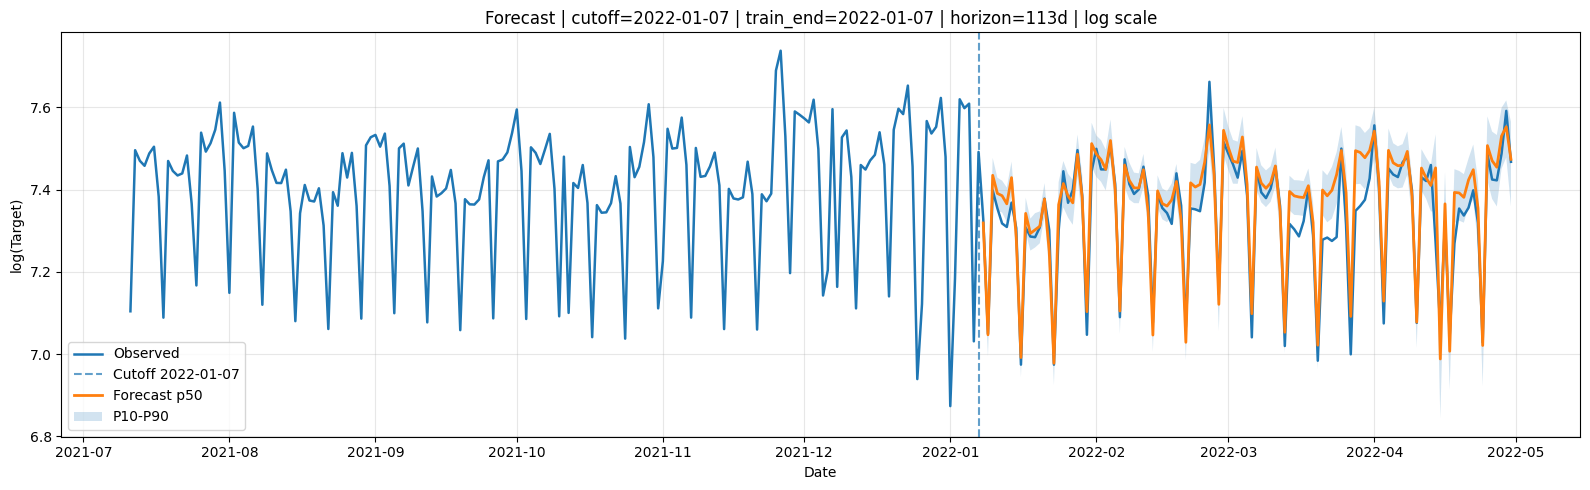

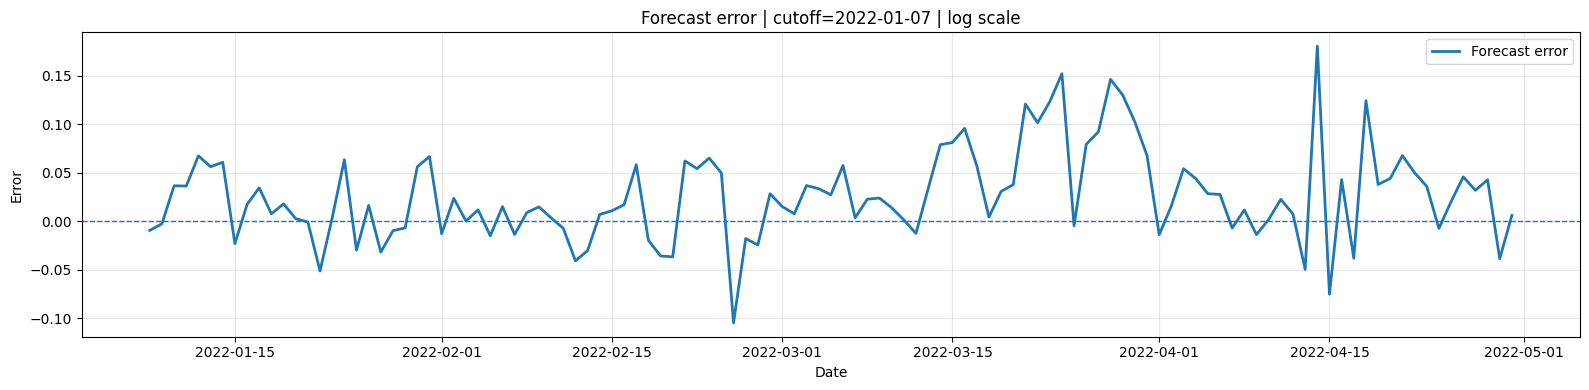

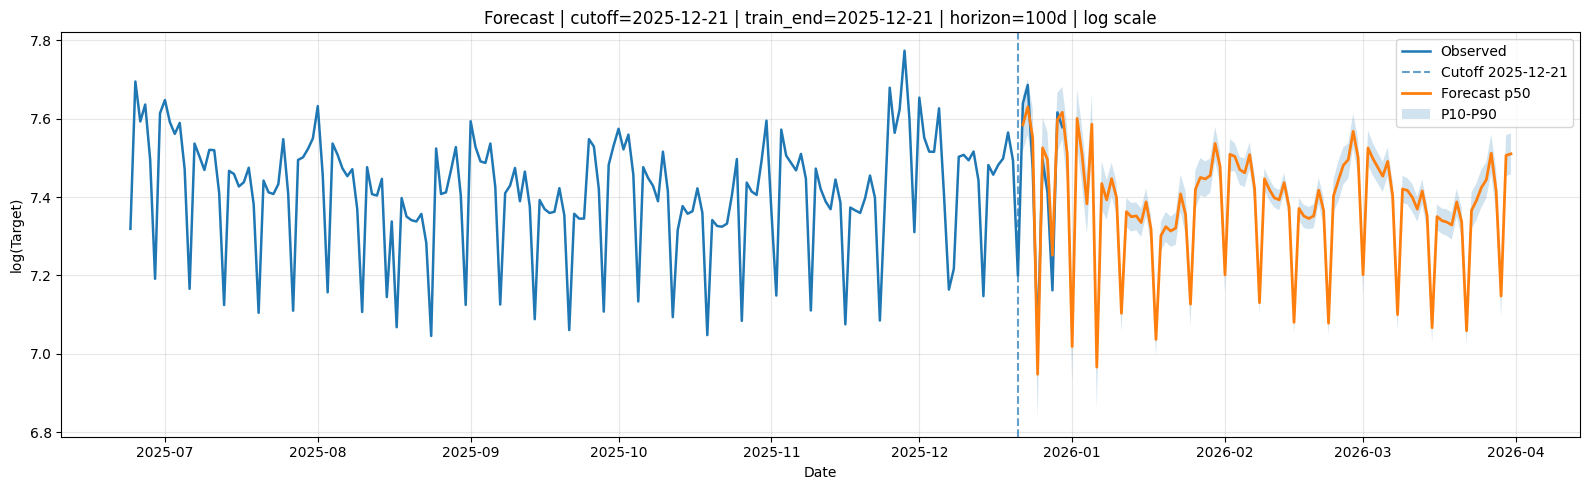

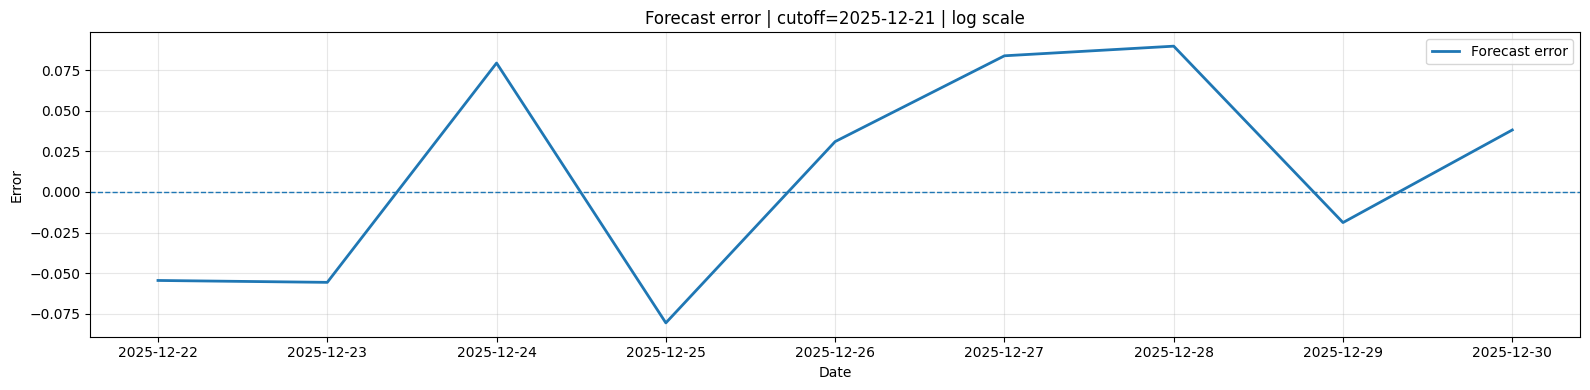

In [ ]:
first_cutoff = cutoff_summary_df["cutoff_date"].min()
last_cutoff = cutoff_summary_df["cutoff_date"].max()

plot_cutoff_forecast(pred_store, y_all, first_cutoff, history_days=180, visualize_in_log=True)
plot_cutoff_forecast(pred_store, y_all, last_cutoff, history_days=180, visualize_in_log=True)

#### 8-Monthly comparison by anchor

In [ ]:
# =========================
# 8) DASHBOARD INTERACTIVO CON DESPLEGABLES
# =========================

def show_rolling_dashboard(daily_eval_df, monthly_eval_df,
                           default_cutoff_day=7,
                           default_month_offset=0):
    available_cutoff_days = sorted(monthly_eval_df["cutoff_day"].dropna().unique().tolist())
    available_offsets = sorted(monthly_eval_df["month_offset"].dropna().unique().tolist())

    if not available_cutoff_days:
        print("No hay cutoff_days disponibles.")
        return

    if not available_offsets:
        print("No hay month_offsets disponibles.")
        return

    if default_cutoff_day not in available_cutoff_days:
        default_cutoff_day = available_cutoff_days[0]

    if default_month_offset not in available_offsets:
        default_month_offset = available_offsets[0]

    cutoff_dropdown = widgets.Dropdown(
        options=available_cutoff_days,
        value=default_cutoff_day,
        description="Día corte:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="220px")
    )

    offset_dropdown = widgets.Dropdown(
        options=[(f"{o} - {offset_label(o)}", o) for o in available_offsets],
        value=default_month_offset,
        description="Mes forecast:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="260px")
    )

    def _render(cutoff_day, month_offset):
        print(f"Selección -> cutoff_day={cutoff_day}, month_offset={month_offset} ({offset_label(month_offset)})\n")

        print("=== Daily rolling vs observed ===")
        plot_daily_rolling_vs_observed(
            daily_eval_df=daily_eval_df,
            cutoff_day=cutoff_day,
            month_offset=month_offset
        )

        print("\n=== Monthly rolling vs observed ===")
        plot_monthly_rolling_vs_observed(
            monthly_eval_df=monthly_eval_df,
            cutoff_day=cutoff_day,
            month_offset=month_offset,
            visualize_in_log=VISUALIZE_MONTHLY_IN_LOG
        )

    ui = widgets.HBox([cutoff_dropdown, offset_dropdown])
    out = widgets.interactive_output(
        _render,
        {
            "cutoff_day": cutoff_dropdown,
            "month_offset": offset_dropdown
        }
    )

    display(ui, out)

In [ ]:
show_rolling_dashboard(
    daily_eval_df=daily_eval_df,
    monthly_eval_df=monthly_eval_df,
    default_cutoff_day=DEFAULT_WIDGET_CUTOFF_DAY,
    default_month_offset=DEFAULT_WIDGET_MONTH_OFFSET
)

Output()

#### 9-Summary by monthly horizon type

In [ ]:
# =========================
# 9) RESUMEN SEGMENTADO
# =========================

def build_segment_summary(daily_eval_df, monthly_eval_df):
    # -------------------------
    # Resumen diario
    # -------------------------
    daily_obs = daily_eval_df[daily_eval_df["has_observed"]].copy()

    daily_summary = (
        daily_obs
        .groupby(["cutoff_day", "forecast_month_offset"], as_index=False)
        .apply(lambda g: pd.Series({
            "n_daily_points": len(g),
            "daily_MAPE": mape(g["y_true"], g["yhat_p50"]),
            "daily_wMAPE": wmape(g["y_true"], g["yhat_p50"]),
            "daily_RMSE": rmse(g["y_true"], g["yhat_p50"]),
        }))
        .reset_index(drop=True)
    )

    daily_summary["month_label"] = daily_summary["forecast_month_offset"].map(offset_label)

    # -------------------------
    # Resumen mensual
    # -------------------------
    monthly_obs = monthly_eval_df[monthly_eval_df["has_full_observed_month"]].copy()

    monthly_summary = (
        monthly_obs
        .groupby(["cutoff_day", "month_offset"], as_index=False)
        .apply(lambda g: pd.Series({
            "n_months": len(g),
            "monthly_MAPE": mape(g["monthly_true_sum"], g["monthly_pred_sum"]),
            "monthly_wMAPE": wmape(g["monthly_true_sum"], g["monthly_pred_sum"]),
            "monthly_RMSE": rmse(g["monthly_true_sum"], g["monthly_pred_sum"]),
        }))
        .reset_index(drop=True)
    )

    monthly_summary["month_label"] = monthly_summary["month_offset"].map(offset_label)

    return daily_summary, monthly_summary

daily_summary_df, monthly_summary_df = build_segment_summary(daily_eval_df, monthly_eval_df)

print("=== Resumen diario ===")
display(
    daily_summary_df[
        ["cutoff_day", "forecast_month_offset", "month_label",
         "n_daily_points", "daily_MAPE", "daily_wMAPE", "daily_RMSE"]
    ]
)

print("\n=== Resumen mensual ===")
display(
    monthly_summary_df[
        ["cutoff_day", "month_offset", "month_label",
         "n_months", "monthly_MAPE", "monthly_wMAPE", "monthly_RMSE"]
    ]
)

=== Resumen diario ===


/tmp/ipykernel_2547/320241826.py:14: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_2547/320241826.py:33: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,cutoff_day,forecast_month_offset,month_label,n_daily_points,daily_MAPE,daily_wMAPE,daily_RMSE
0,7,0,Mes actual,1124.0,3.104314,3.091206,70.499093
1,7,1,M+1,1429.0,3.298747,3.271284,74.491788
2,7,2,M+2,1401.0,3.667218,3.638989,82.726013
3,7,3,M+3,1370.0,3.634864,3.623490,80.668592
4,14,0,Mes actual,788.0,3.322124,3.323258,76.825169
5,14,1,M+1,1429.0,3.338289,3.282274,75.090045
6,14,2,M+2,1401.0,3.585378,3.558934,80.085332
7,14,3,M+3,1370.0,3.647623,3.631126,80.535216
8,21,0,Mes actual,452.0,4.293132,4.247039,93.888617
9,21,1,M+1,1429.0,3.181480,3.142754,71.911407



=== Resumen mensual ===


,cutoff_day,month_offset,month_label,n_months,monthly_MAPE,monthly_wMAPE,monthly_RMSE
0,7,0,Mes actual,47.0,0.931212,0.929483,592.871256
1,7,1,M+1,46.0,1.421204,1.415529,879.579447
2,7,2,M+2,45.0,1.699289,1.697807,1231.727442
3,7,3,M+3,44.0,1.860228,1.862900,1182.239571
4,14,0,Mes actual,47.0,0.767220,0.767830,468.587878
5,14,1,M+1,46.0,1.420745,1.405241,875.890816
6,14,2,M+2,45.0,1.692381,1.686249,1151.401106
7,14,3,M+3,44.0,1.810721,1.806054,1179.807416
8,21,0,Mes actual,47.0,0.532551,0.532673,330.658304
9,21,1,M+1,46.0,1.254964,1.243834,793.824915
